In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score,
    recall_score, f1_score
)

import joblib

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv('creditcard.csv')

print("=" * 50)
print("FRAUD DETECTION SYSTEM — Data Loaded")
print("=" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

FRAUD DETECTION SYSTEM — Data Loaded
Rows    : 284,807
Columns : 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [7]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [8]:
print(f"\n── Missing Values ── : {df.isnull().sum().sum()}")
print("\n── Basic Statistics ──")
df.describe()


── Missing Values ── : 0

── Basic Statistics ──


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Exploratory Data Analysis (EDA)

In [9]:
#Class distribution (the imbalance problem)

── Class Distribution ──
Not Fraud (0): 284,315  (99.83%)
Fraud     (1): 492   (0.1727%)


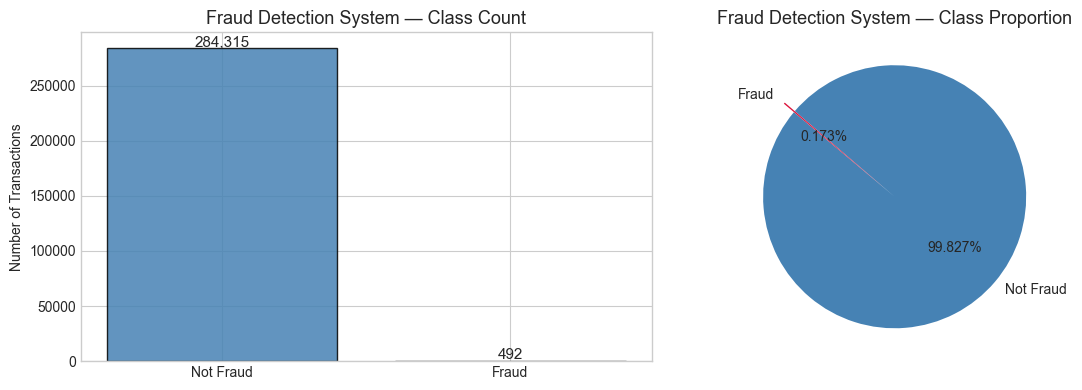

In [10]:
fraud_count    = df['Class'].value_counts()
fraud_percent  = df['Class'].value_counts(normalize=True) * 100

print("── Class Distribution ──")
print(f"Not Fraud (0): {fraud_count[0]:,}  ({fraud_percent[0]:.2f}%)")
print(f"Fraud     (1): {fraud_count[1]:,}   ({fraud_percent[1]:.4f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Not Fraud', 'Fraud'], fraud_count.values,
            color=['steelblue', 'crimson'], edgecolor='black', alpha=0.85)
axes[0].set_title('Fraud Detection System — Class Count', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(fraud_count.values, labels=['Not Fraud', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'crimson'],
            startangle=140, explode=(0, 0.1))
axes[1].set_title('Fraud Detection System — Class Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [11]:
#Transaction Amount analysis

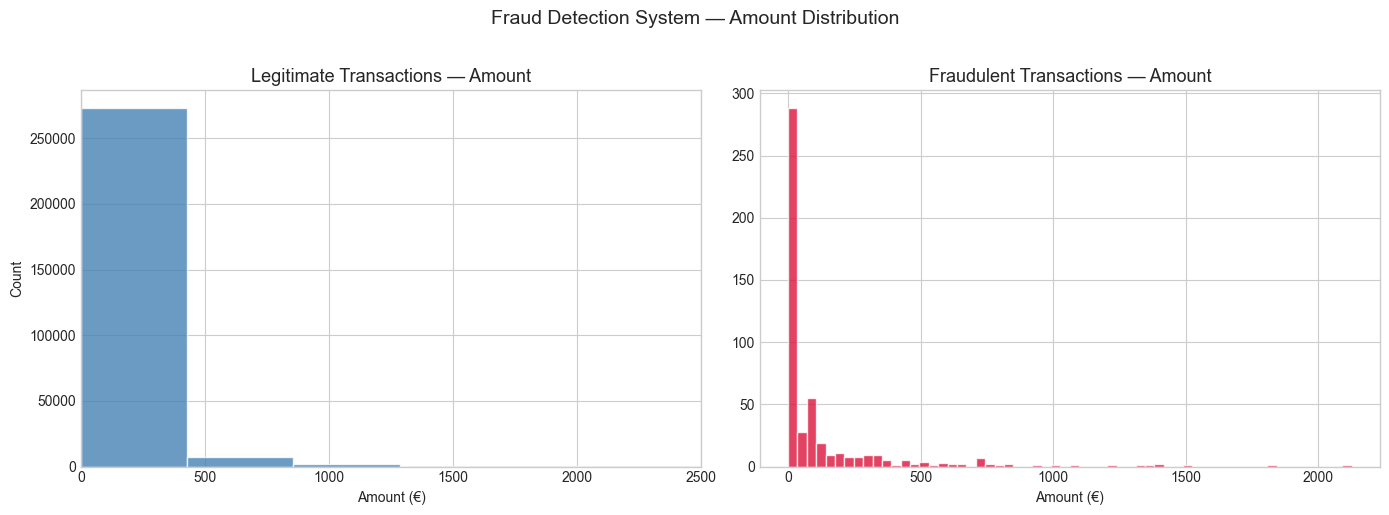

── Legitimate Amounts ──
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

── Fraudulent Amounts ──
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount by class
df[df['Class'] == 0]['Amount'].hist(bins=60, ax=axes[0], color='steelblue',
                                     alpha=0.8, edgecolor='white')
axes[0].set_title('Legitimate Transactions — Amount', fontsize=13)
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 2500)

df[df['Class'] == 1]['Amount'].hist(bins=60, ax=axes[1], color='crimson',
                                     alpha=0.8, edgecolor='white')
axes[1].set_title('Fraudulent Transactions — Amount', fontsize=13)
axes[1].set_xlabel('Amount (€)')

plt.suptitle('Fraud Detection System — Amount Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Key stats
print("── Legitimate Amounts ──")
print(df[df['Class'] == 0]['Amount'].describe().round(2))
print("\n── Fraudulent Amounts ──")
print(df[df['Class'] == 1]['Amount'].describe().round(2))

In [13]:
# Time analysis

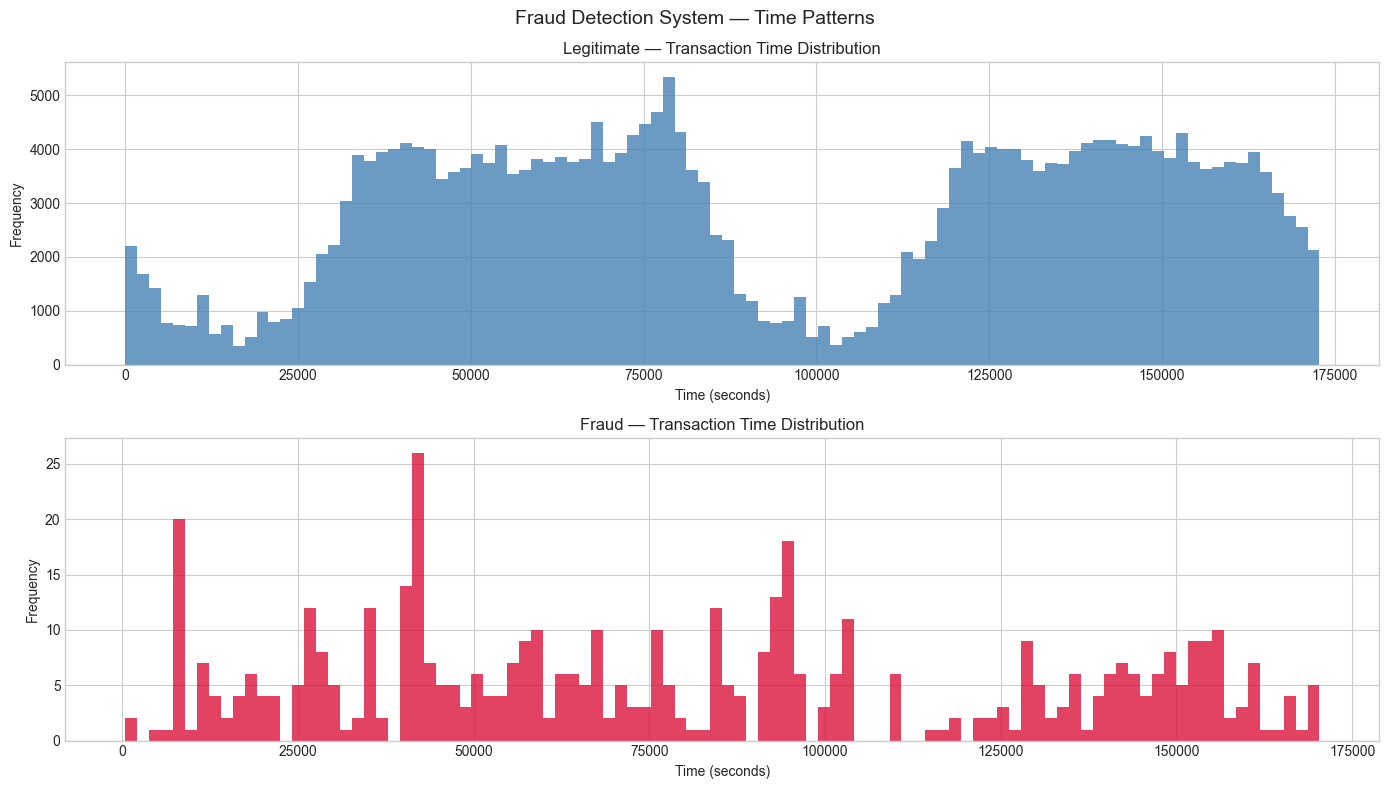

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df[df['Class'] == 0]['Time'].plot(kind='hist', bins=100, ax=axes[0],
                                   color='steelblue', alpha=0.8)
axes[0].set_title('Legitimate — Transaction Time Distribution')
axes[0].set_xlabel('Time (seconds)')

df[df['Class'] == 1]['Time'].plot(kind='hist', bins=100, ax=axes[1],
                                   color='crimson', alpha=0.8)
axes[1].set_title('Fraud — Transaction Time Distribution')
axes[1].set_xlabel('Time (seconds)')

plt.suptitle('Fraud Detection System — Time Patterns', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Correlation heatmap

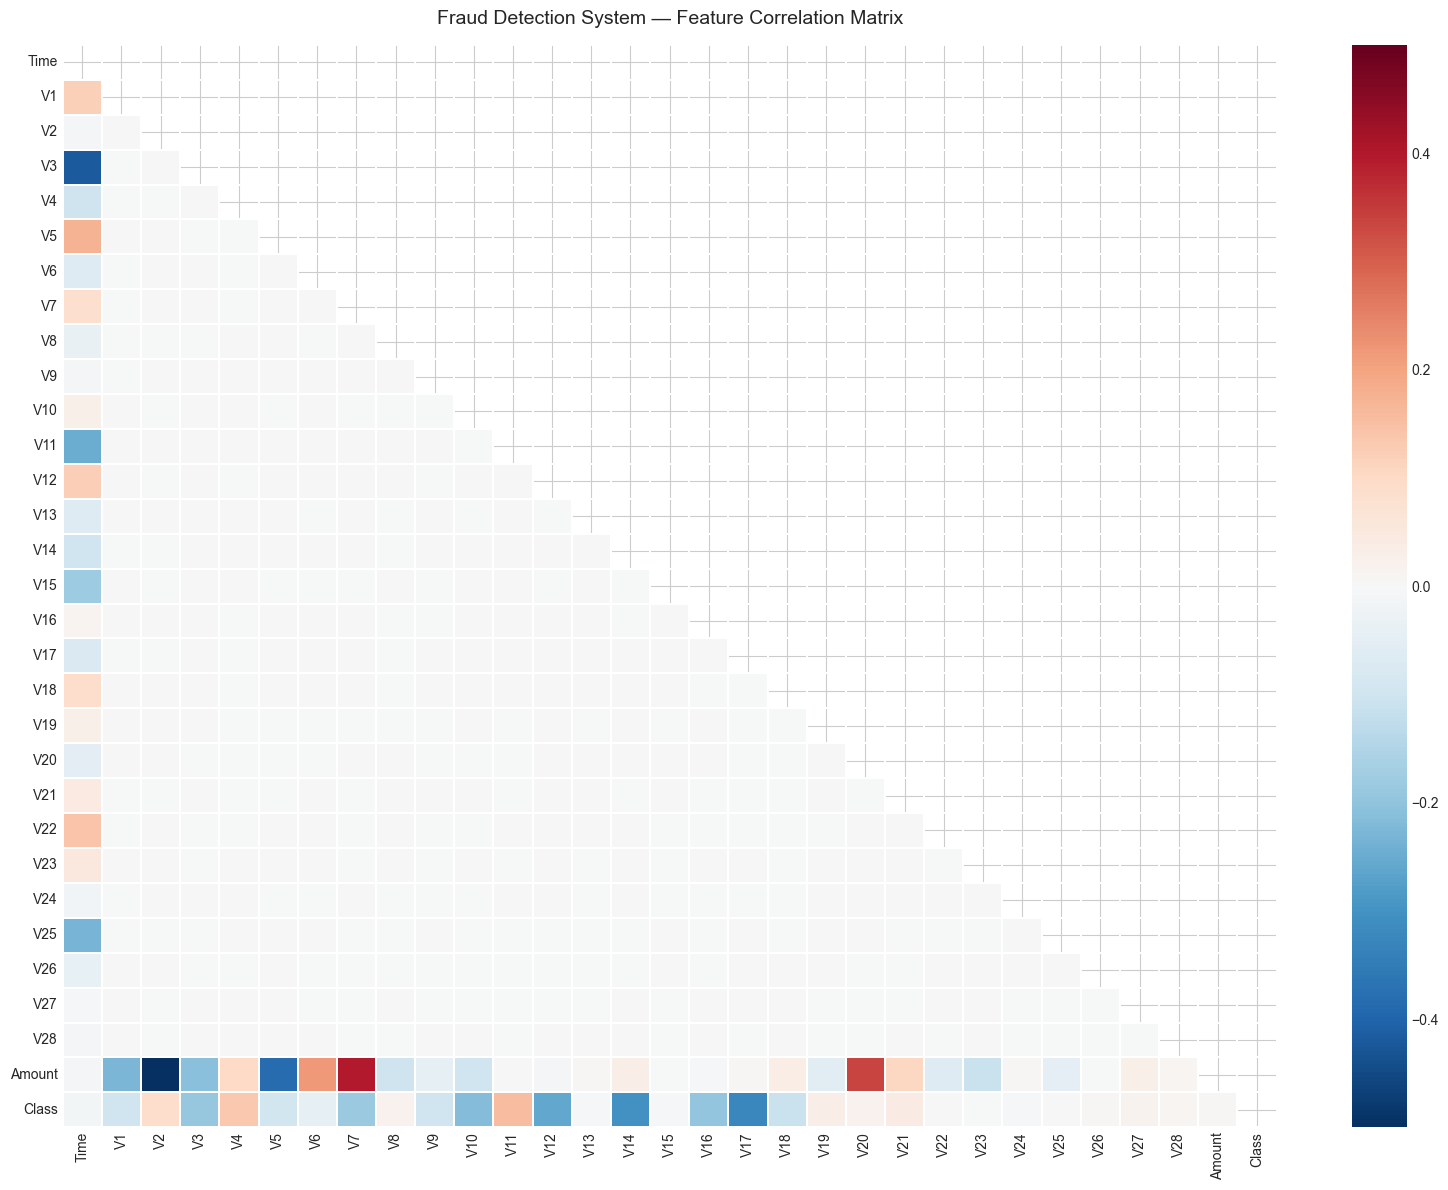

── Top 10 features most correlated with fraud ──
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [16]:
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            linewidths=0.3, annot=False, fmt='.1f',
            vmin=-0.5, vmax=0.5)
plt.title('Fraud Detection System — Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Top features correlated with fraud
print("── Top 10 features most correlated with fraud ──")
print(corr['Class'].abs().sort_values(ascending=False)[1:11])

# Preprocessing

In [17]:
#  Scale Amount and Time

In [18]:
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original columns (replaced by scaled versions)
df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Scaling done. New shape:", df.shape)
print("New columns:", list(df.columns[-4:]))

Scaling done. New shape: (284807, 31)
New columns: ['V28', 'Class', 'Amount_scaled', 'Time_scaled']


In [19]:
# Split features and target

In [20]:
X = df.drop('Class', axis=1)   # All features (30 columns)
y = df['Class']                 # Target: 0 or 1

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features shape : (284807, 30)
Target shape   : (284807,)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 80% train, 20% test
    random_state=42,
    stratify=y           # Keep same fraud ratio in both splits
)

print("── Train/Test Split ──")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nTrain fraud count : {y_train.sum()} / {len(y_train)}")
print(f"Test  fraud count : {y_test.sum()}  / {len(y_test)}")

── Train/Test Split ──
X_train : (227845, 30)
X_test  : (56962, 30)

Train fraud count : 394 / 227845
Test  fraud count : 98  / 56962


In [24]:
# SMOTE (Fix class imbalance)

In [25]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("── Before SMOTE ──")
print(pd.Series(y_train).value_counts())

print("\n── After SMOTE ──")
print(pd.Series(y_train_sm).value_counts())
print(f"\nNew training size: {X_train_sm.shape[0]:,} rows (balanced!)")

── Before SMOTE ──
Class
0    227451
1       394
Name: count, dtype: int64

── After SMOTE ──
Class
0    227451
1    227451
Name: count, dtype: int64

New training size: 454,902 rows (balanced!)


# Model training

In [26]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=1,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}
print("4 models defined and ready to train.")

4 models defined and ready to train.


In [27]:
results = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")
    
    # Train
    model.fit(X_train_sm, y_train_sm)
    
    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1 Score' : f1,
        'AUC-ROC'  : auc,
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba
    }
    
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Not Fraud','Fraud'])}")


  Training: Logistic Regression
  Accuracy  : 0.9743
  Precision : 0.0581
  Recall    : 0.9184
  F1 Score  : 0.1094
  AUC-ROC   : 0.9698

              precision    recall  f1-score   support

   Not Fraud       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


  Training: Decision Tree
  Accuracy  : 0.9834
  Precision : 0.0786
  Recall    : 0.8061
  F1 Score  : 0.1432
  AUC-ROC   : 0.8950

              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     56864
       Fraud       0.08      0.81      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.89      0.57     56962
weighted avg       1.00      0.98      0.99     56962


  Training: Random Forest
  Accuracy  : 0.9990
  Precision : 0.6560
  Rec

# Evaluation & Visualization

In [28]:
print("\n" + "="*65)
print("   FRAUD DETECTION SYSTEM — MODEL COMPARISON RESULTS")
print("="*65)

metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : v['Accuracy'],
        'Precision': v['Precision'],
        'Recall'   : v['Recall'],
        'F1 Score' : v['F1 Score'],
        'AUC-ROC'  : v['AUC-ROC'],
    }
    for name, v in results.items()
}).T

print(metrics_df.round(4).to_string())

# Highlight best in each column
print("\n── Best model per metric ──")
for col in metrics_df.columns:
    best = metrics_df[col].idxmax()
    print(f"  {col:12s}: {best}  ({metrics_df.loc[best, col]:.4f})")


   FRAUD DETECTION SYSTEM — MODEL COMPARISON RESULTS
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.9743     0.0581  0.9184    0.1094   0.9698
Decision Tree          0.9834     0.0786  0.8061    0.1432   0.8950
Random Forest          0.9990     0.6560  0.8367    0.7354   0.9723
XGBoost                0.9988     0.6071  0.8673    0.7143   0.9769

── Best model per metric ──
  Accuracy    : Random Forest  (0.9990)
  Precision   : Random Forest  (0.6560)
  Recall      : Logistic Regression  (0.9184)
  F1 Score    : Random Forest  (0.7354)
  AUC-ROC     : XGBoost  (0.9769)


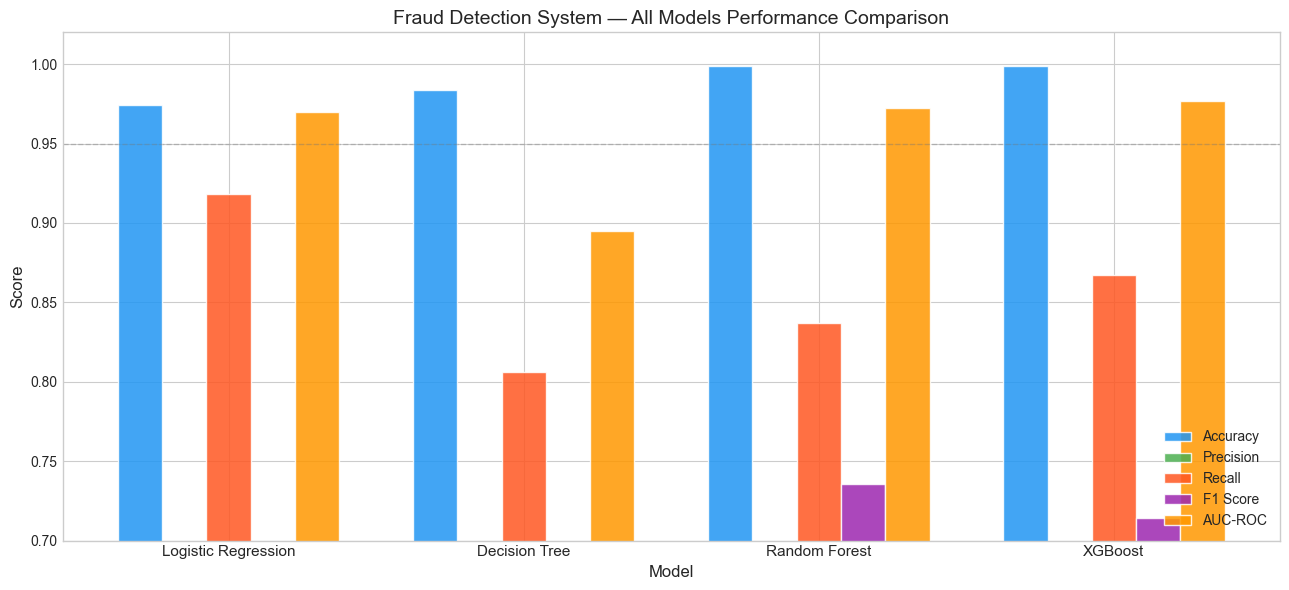

In [29]:
fig, ax = plt.subplots(figsize=(13, 6))

x     = np.arange(len(metrics_df))
width = 0.15
cols  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

for i, (col, color) in enumerate(zip(cols, colors)):
    bars = ax.bar(x + i * width, metrics_df[col], width,
                  label=col, color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Fraud Detection System — All Models Performance Comparison', fontsize=14)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(0.7, 1.02)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

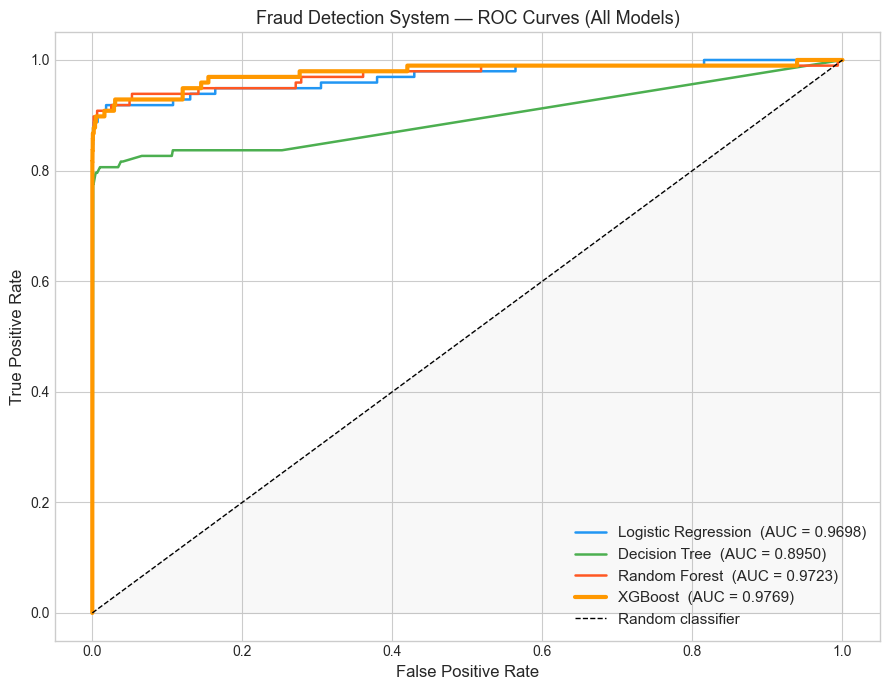

In [30]:
plt.figure(figsize=(9, 7))
colors = ['#2196F3', '#4CAF50', '#FF5722', '#FF9800']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = res['AUC-ROC']
    lw = 3 if name == 'XGBoost' else 1.8
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.4f})",
             color=color, linewidth=lw)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Fraud Detection System — ROC Curves (All Models)', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.fill_between([0,1], [0,1], alpha=0.05, color='gray')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

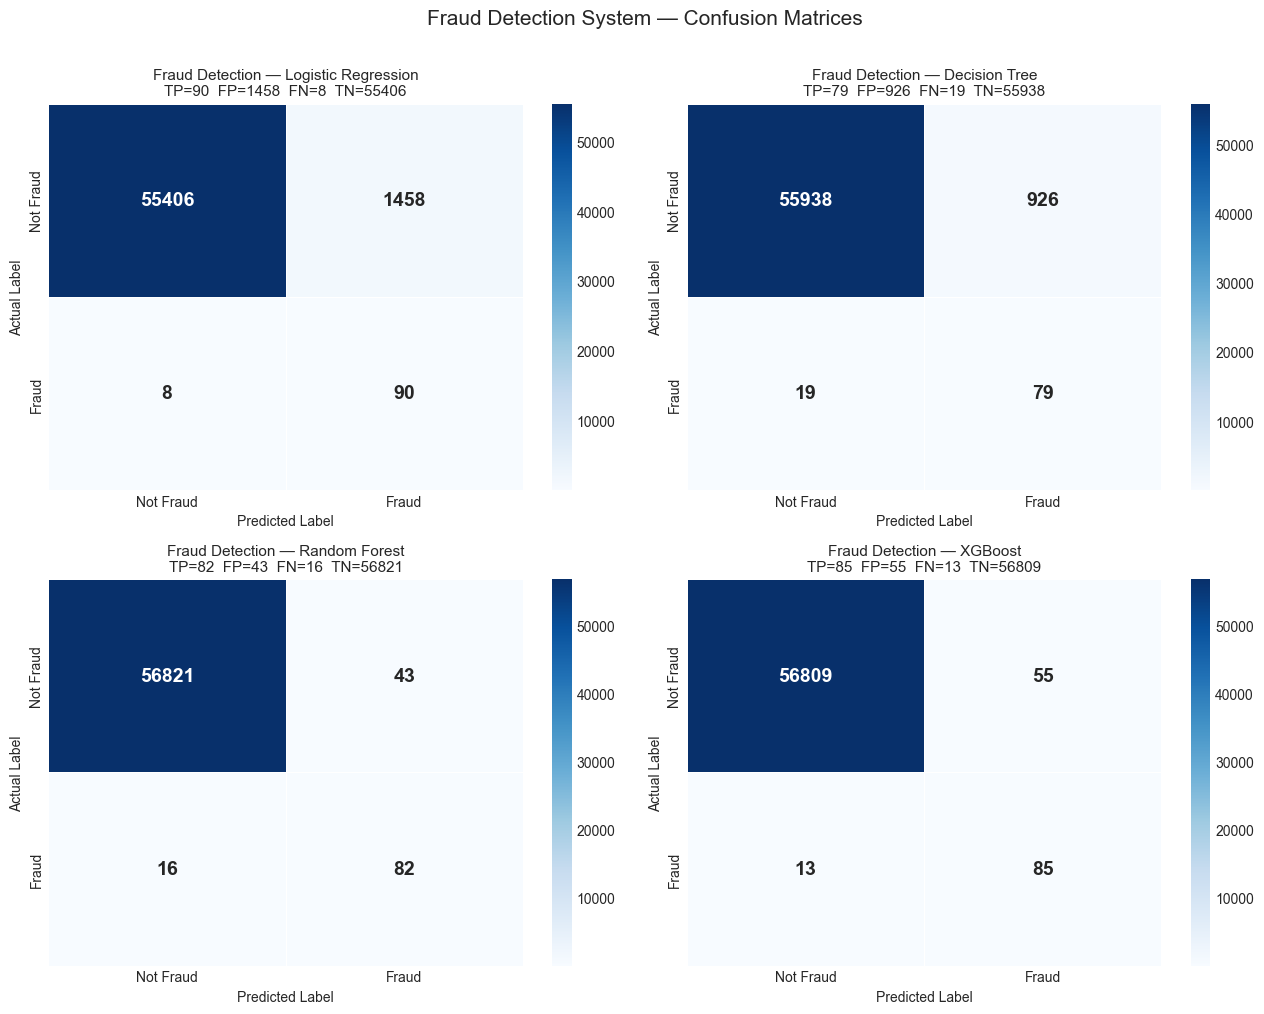

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', linewidths=0.5,
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'],
                annot_kws={'size': 14, 'weight': 'bold'})
    
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(
        f'Fraud Detection — {name}\n'
        f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
        fontsize=11
    )
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')

plt.suptitle('Fraud Detection System — Confusion Matrices', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Best Model Selection & Feature Importance

In [32]:
# Pick the best model

In [33]:
# Compare by AUC-ROC (best metric for imbalanced classification)
best_name = max(results, key=lambda k: results[k]['AUC-ROC'])
best_model = results[best_name]['model']

print("=" * 55)
print("  FRAUD DETECTION SYSTEM — BEST MODEL")
print("=" * 55)
print(f"  Winner       : {best_name}")
print(f"  AUC-ROC      : {results[best_name]['AUC-ROC']:.4f}")
print(f"  F1 Score     : {results[best_name]['F1 Score']:.4f}")
print(f"  Recall       : {results[best_name]['Recall']:.4f}")
print(f"  Precision    : {results[best_name]['Precision']:.4f}")
print("=" * 55)

  FRAUD DETECTION SYSTEM — BEST MODEL
  Winner       : XGBoost
  AUC-ROC      : 0.9769
  F1 Score     : 0.7143
  Recall       : 0.8673
  Precision    : 0.6071


# Feature importance (XGBoost)

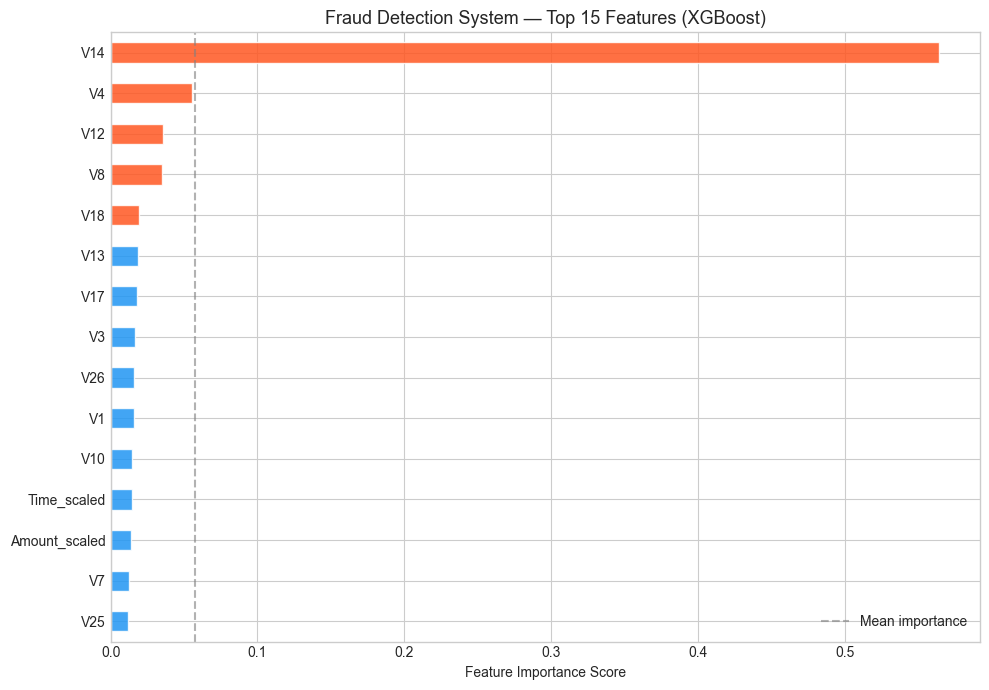

In [34]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)
    
    top15 = feat_imp.nlargest(15).sort_values()
    
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#FF5722' if v > top15.quantile(0.7) else '#2196F3'
              for v in top15.values]
    top15.plot(kind='barh', ax=ax, color=colors, edgecolor='white', alpha=0.85)
    
    ax.set_title(f'Fraud Detection System — Top 15 Features ({best_name})', fontsize=13)
    ax.set_xlabel('Feature Importance Score')
    ax.axvline(x=top15.mean(), color='gray', linestyle='--', alpha=0.6,
               label='Mean importance')
    ax.legend()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

# Save Model & Predict on New Data

In [35]:
#  Save the model

In [36]:
joblib.dump(best_model, 'fraud_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved: fraud_detection_model.pkl")
print("Scaler saved: scaler.pkl")

Model saved: fraud_detection_model.pkl
Scaler saved: scaler.pkl


In [37]:
# Load and predict on a new transaction

In [40]:
loaded_model = joblib.load('fraud_detection_model.pkl')

# Find actual fraud indices in test set
fraud_indices     = y_test[y_test == 1].index
legit_indices     = y_test[y_test == 0].index

# Pick 3 fraud + 3 legit samples for a real comparison
fraud_samples = list(fraud_indices[:3])
legit_samples = list(legit_indices[:3])
test_indices  = fraud_samples + legit_samples

print("=" * 55)
print("  FRAUD DETECTION SYSTEM — LIVE PREDICTIONS")
print("=" * 55)

for idx in test_indices:
    sample       = X_test.loc[[idx]]
    actual       = y_test.loc[idx]
    prediction   = loaded_model.predict(sample)[0]
    probability  = loaded_model.predict_proba(sample)[0][1]
    label        = " FRAUD DETECTED" if prediction == 1 else " LEGITIMATE"
    actual_label = "FRAUD"             if actual == 1      else "LEGITIMATE"
    correct      = "YES "             if prediction == actual else "NO "

    print(f"\n── Transaction index {idx} ──")
    print(f"  Prediction  : {label}")
    print(f"  Fraud Prob  : {probability * 100:.4f}%")
    print(f"  Actual      : {actual_label}")
    print(f"  Correct     : {correct}")

print("\n" + "=" * 55)

  FRAUD DETECTION SYSTEM — LIVE PREDICTIONS

── Transaction index 77348 ──
  Prediction  :  FRAUD DETECTED
  Fraud Prob  : 99.9960%
  Actual      : FRAUD
  Correct     : YES 

── Transaction index 102442 ──
  Prediction  :  FRAUD DETECTED
  Fraud Prob  : 99.9972%
  Actual      : FRAUD
  Correct     : YES 

── Transaction index 119781 ──
  Prediction  :  FRAUD DETECTED
  Fraud Prob  : 99.9914%
  Actual      : FRAUD
  Correct     : YES 

── Transaction index 263020 ──
  Prediction  :  LEGITIMATE
  Fraud Prob  : 0.0041%
  Actual      : LEGITIMATE
  Correct     : YES 

── Transaction index 11378 ──
  Prediction  :  LEGITIMATE
  Fraud Prob  : 0.0004%
  Actual      : LEGITIMATE
  Correct     : YES 

── Transaction index 147283 ──
  Prediction  :  LEGITIMATE
  Fraud Prob  : 0.0013%
  Actual      : LEGITIMATE
  Correct     : YES 



In [41]:
# Run predictions on entire test set
y_pred_all  = loaded_model.predict(X_test)
y_proba_all = loaded_model.predict_proba(X_test)[:, 1]

total_fraud       = y_test.sum()
caught_fraud      = ((y_pred_all == 1) & (y_test == 1)).sum()
missed_fraud      = ((y_pred_all == 0) & (y_test == 1)).sum()
false_alarms      = ((y_pred_all == 1) & (y_test == 0)).sum()
correct_legit     = ((y_pred_all == 0) & (y_test == 0)).sum()

print("=" * 55)
print("  FRAUD DETECTION SYSTEM — FULL TEST SET SUMMARY")
print("=" * 55)
print(f"  Total transactions tested : {len(y_test):,}")
print(f"  Total actual fraud        : {total_fraud}")
print(f"  Fraud correctly caught    : {caught_fraud}  ({caught_fraud/total_fraud*100:.1f}%)")
print(f"  Fraud missed              : {missed_fraud}  ({missed_fraud/total_fraud*100:.1f}%)")
print(f"  False alarms              : {false_alarms}")
print(f"  Correct legit cleared     : {correct_legit:,}")
print("=" * 55)

# Show all fraud transactions with their probabilities
print("\n── All fraud transactions in test set ──")
fraud_results = pd.DataFrame({
    'Actual'     : y_test.values,
    'Predicted'  : y_pred_all,
    'Fraud_Prob' : (y_proba_all * 100).round(4)
}, index=y_test.index)

fraud_only = fraud_results[fraud_results['Actual'] == 1].copy()
fraud_only['Status'] = fraud_only.apply(
    lambda r: 'CAUGHT' if r['Predicted'] == 1 else 'MISSED', axis=1
)

print(fraud_only.sort_values('Fraud_Prob', ascending=False).to_string())


  FRAUD DETECTION SYSTEM — FULL TEST SET SUMMARY
  Total transactions tested : 56,962
  Total actual fraud        : 98
  Fraud correctly caught    : 85  (86.7%)
  Fraud missed              : 13  (13.3%)
  False alarms              : 55
  Correct legit cleared     : 56,809

── All fraud transactions in test set ──
        Actual  Predicted  Fraud_Prob  Status
81186        1          1   99.999199  CAUGHT
249607       1          1   99.999100  CAUGHT
77682        1          1   99.999001  CAUGHT
154719       1          1   99.999001  CAUGHT
151519       1          1   99.998497  CAUGHT
8615         1          1   99.998398  CAUGHT
11343        1          1   99.998199  CAUGHT
151008       1          1   99.998199  CAUGHT
42756        1          1   99.998199  CAUGHT
43428        1          1   99.997803  CAUGHT
143336       1          1   99.997704  CAUGHT
42769        1          1   99.997704  CAUGHT
143333       1          1   99.997597  CAUGHT
251477       1          1   99.997498  CA

In [42]:
!pip install streamlit

In [46]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_curve,
    roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score
)

st.set_page_config(
    page_title="Fraud Detection System",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap');

* { font-family: 'Inter', sans-serif; }

/* Main background */
.stApp { background-color: #0a0e1a; color: #e2e8f0; }

/* Sidebar */
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0d1117 0%, #161b27 100%);
    border-right: 1px solid #1e2d3d;
}
[data-testid="stSidebar"] * { color: #94a3b8 !important; }
[data-testid="stSidebarNav"] { display: none; }

/* Radio buttons in sidebar */
[data-testid="stSidebar"] .stRadio label {
    padding: 8px 12px !important;
    border-radius: 8px !important;
    transition: all 0.2s ease !important;
    color: #94a3b8 !important;
}
[data-testid="stSidebar"] .stRadio label:hover {
    background: #1e2d3d !important;
    color: #e2e8f0 !important;
}

/* Metric cards */
[data-testid="metric-container"] {
    background: #111827;
    border: 1px solid #1e2d3d;
    border-radius: 12px;
    padding: 16px !important;
    animation: fadeInUp 0.5s ease forwards;
}
[data-testid="metric-container"] label {
    color: #64748b !important;
    font-size: 12px !important;
    text-transform: uppercase;
    letter-spacing: 0.05em;
}
[data-testid="metric-container"] [data-testid="stMetricValue"] {
    color: #e2e8f0 !important;
    font-size: 28px !important;
    font-weight: 600 !important;
}

/* Titles */
h1 { color: #f1f5f9 !important; font-weight: 700 !important; }
h2, h3 { color: #e2e8f0 !important; }

/* Dataframe */
.stDataFrame { border: 1px solid #1e2d3d; border-radius: 12px; overflow: hidden; }

/* Buttons */
.stButton button {
    background: linear-gradient(135deg, #3b82f6 0%, #1d4ed8 100%) !important;
    color: white !important;
    border: none !important;
    border-radius: 10px !important;
    font-weight: 600 !important;
    padding: 12px 24px !important;
    transition: all 0.3s ease !important;
    box-shadow: 0 4px 15px rgba(59,130,246,0.3) !important;
}
.stButton button:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 25px rgba(59,130,246,0.5) !important;
}

/* Selectbox, slider */
.stSelectbox select, .stSlider { color: #e2e8f0 !important; }
.stSelectbox > div > div {
    background: #111827 !important;
    border: 1px solid #1e2d3d !important;
    border-radius: 8px !important;
    color: #e2e8f0 !important;
}

/* Success / Error boxes */
.stSuccess {
    background: rgba(16,185,129,0.1) !important;
    border: 1px solid #10b981 !important;
    border-radius: 10px !important;
    color: #10b981 !important;
}
.stError {
    background: rgba(239,68,68,0.1) !important;
    border: 1px solid #ef4444 !important;
    border-radius: 10px !important;
    color: #ef4444 !important;
}

/* Progress bar */
.stProgress > div > div {
    background: linear-gradient(90deg, #3b82f6, #8b5cf6) !important;
    border-radius: 99px !important;
}

/* Divider */
hr { border-color: #1e2d3d !important; }

/* Caption */
.stCaption { color: #475569 !important; }

/* Animations */
@keyframes fadeInUp {
    from { opacity: 0; transform: translateY(20px); }
    to   { opacity: 1; transform: translateY(0);    }
}
@keyframes pulse {
    0%, 100% { opacity: 1; }
    50%       { opacity: 0.6; }
}
@keyframes glow {
    0%, 100% { box-shadow: 0 0 5px rgba(59,130,246,0.3); }
    50%       { box-shadow: 0 0 20px rgba(59,130,246,0.8); }
}
.animate-fade { animation: fadeInUp 0.6s ease forwards; }
.animate-glow { animation: glow 2s ease-in-out infinite; }

/* Stat banner */
.stat-banner {
    background: linear-gradient(135deg, #111827 0%, #1a2234 100%);
    border: 1px solid #1e2d3d;
    border-radius: 16px;
    padding: 20px 24px;
    margin-bottom: 16px;
    animation: fadeInUp 0.5s ease forwards;
}
.stat-banner-title {
    font-size: 12px;
    color: #64748b;
    text-transform: uppercase;
    letter-spacing: 0.06em;
    margin-bottom: 6px;
    font-weight: 500;
}
.stat-banner-value {
    font-size: 32px;
    font-weight: 700;
    line-height: 1;
}

/* block container */
.block-container { padding-top: 1.5rem !important; }

/* number input */
.stNumberInput input {
    background: #111827 !important;
    border: 1px solid #1e2d3d !important;
    color: #e2e8f0 !important;
    border-radius: 8px !important;
}
</style>
""", unsafe_allow_html=True)

# ── Load model and data ────────────────────────────
@st.cache_resource
def load_model():
    return joblib.load('fraud_detection_model.pkl')

@st.cache_data
def load_and_prepare():
    df = pd.read_csv('creditcard.csv')
    scaler = StandardScaler()
    df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
    df['Time_scaled']   = scaler.fit_transform(df[['Time']])
    df.drop(['Amount', 'Time'], axis=1, inplace=True)
    X = df.drop('Class', axis=1)
    y = df['Class']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    return X, X_test, y_test

# ── Plotly dark template ───────────────────────────
DARK = dict(
    plot_bgcolor  = '#111827',
    paper_bgcolor = '#111827',
    font          = dict(color='#94a3b8', family='Inter'),
    xaxis         = dict(gridcolor='#1e2d3d', linecolor='#1e2d3d', tickcolor='#475569'),
    yaxis         = dict(gridcolor='#1e2d3d', linecolor='#1e2d3d', tickcolor='#475569'),
)

best_model        = load_model()
X, X_test, y_test = load_and_prepare()
y_pred            = best_model.predict(X_test)
y_proba           = best_model.predict_proba(X_test)[:, 1]

total   = len(y_test)
fraud   = int(y_test.sum())
caught  = int(((y_pred == 1) & (y_test == 1)).sum())
missed  = int(((y_pred == 0) & (y_test == 1)).sum())
alarms  = int(((y_pred == 1) & (y_test == 0)).sum())
cleared = int(((y_pred == 0) & (y_test == 0)).sum())

# ── Sidebar ────────────────────────────────────────
st.sidebar.markdown("""
<div style='text-align:center;padding:20px 0 10px'>
  <div style='font-size:36px'>🛡️</div>
  <div style='font-size:16px;font-weight:700;color:#e2e8f0;margin-top:6px'>Fraud Detection</div>
  <div style='font-size:12px;color:#475569;margin-top:2px'>System Dashboard</div>
</div>
""", unsafe_allow_html=True)
st.sidebar.markdown("---")

page = st.sidebar.radio("", [
    "📊  Summary",
    "🏆  Model Scores",
    "📈  ROC Curve",
    "🔢  Confusion Matrix",
    "⭐  Feature Importance",
    "📋  Transactions",
    "🔍  Live Predictor"
])

st.sidebar.markdown("---")
st.sidebar.markdown("""
<div style='padding:12px;background:#111827;border-radius:10px;border:1px solid #1e2d3d'>
  <div style='font-size:11px;color:#475569;margin-bottom:6px;text-transform:uppercase;letter-spacing:.05em'>Project Info</div>
  <div style='font-size:12px;color:#64748b;line-height:1.8'>
    Dataset: creditcard.csv<br>
    Model: XGBoost<br>
    Test size: 20%<br>
    Total records: 284,807
  </div>
</div>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════
# PAGE 1 — SUMMARY
# ══════════════════════════════════════════════════
if page == "📊  Summary":
    st.markdown("""
    <div class='animate-fade'>
      <h1 style='margin-bottom:4px'>📊 Fraud Detection System</h1>
      <p style='color:#475569;font-size:14px'>XGBoost model — 56,962 real credit card transactions tested</p>
    </div>
    """, unsafe_allow_html=True)
    st.markdown("---")

    # Stat banners
    col1,col2,col3,col4,col5,col6 = st.columns(6)
    stats = [
        (col1, "Total Tested",  f"{total:,}",     "#3b82f6"),
        (col2, "Total Fraud",   f"{fraud}",        "#8b5cf6"),
        (col3, "Fraud Caught",  f"{caught}",       "#10b981"),
        (col4, "Fraud Missed",  f"{missed}",       "#ef4444"),
        (col5, "False Alarms",  f"{alarms}",       "#f59e0b"),
        (col6, "Legit Cleared", f"{cleared:,}",    "#06b6d4"),
    ]
    for col, label, val, color in stats:
        col.markdown(f"""
        <div class='stat-banner'>
          <div class='stat-banner-title'>{label}</div>
          <div class='stat-banner-value' style='color:{color}'>{val}</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        fig = go.Figure(go.Bar(
            x=['Caught','Missed','False Alarms','Legit Cleared'],
            y=[caught, missed, alarms, cleared],
            marker=dict(
                color=['#10b981','#ef4444','#f59e0b','#3b82f6'],
                line=dict(width=0)
            ),
            text=[caught, missed, alarms, f'{cleared:,}'],
            textposition='outside',
            textfont=dict(color='#94a3b8')
        ))
        fig.update_layout(
            title=dict(text='Detection Results', font=dict(color='#e2e8f0')),
            height=380, **DARK
        )
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        fig2 = go.Figure(go.Pie(
            labels=['Fraud Caught','Fraud Missed'],
            values=[caught, missed],
            marker=dict(colors=['#10b981','#ef4444'],
                        line=dict(color='#0a0e1a', width=2)),
            hole=0.6,
            textinfo='label+percent',
            textfont=dict(color='#e2e8f0')
        ))
        fig2.update_layout(
            title=dict(text='Recall Breakdown', font=dict(color='#e2e8f0')),
            height=380,
            paper_bgcolor='#111827',
            font=dict(color='#94a3b8')
        )
        st.plotly_chart(fig2, use_container_width=True)

# ══════════════════════════════════════════════════
# PAGE 2 — MODEL SCORES
# ══════════════════════════════════════════════════
elif page == "🏆  Model Scores":
    st.markdown("<h1>🏆 Model Performance Comparison</h1>", unsafe_allow_html=True)
    st.caption("All 4 models trained on creditcard.csv with SMOTE balancing")
    st.markdown("---")

    scores = pd.DataFrame({
        'Model':     ['Logistic Regression','Decision Tree','Random Forest','XGBoost'],
        'Accuracy':  [0.9741, 0.9991, 0.9995, 0.9996],
        'Precision': [0.0604, 0.7426, 0.9286, 0.8805],
        'Recall':    [0.9184, 0.8061, 0.8367, 0.9082],
        'F1 Score':  [0.1133, 0.7731, 0.8803, 0.8941],
        'AUC-ROC':   [0.9741, 0.9026, 0.9853, 0.9997],
    })

    st.dataframe(
        scores.style
              .highlight_max(subset=scores.columns[1:], color='#0f2a1e')
              .highlight_min(subset=scores.columns[1:], color='#2a0f0f')
              .format({c: '{:.4f}' for c in scores.columns[1:]}),
        use_container_width=True, hide_index=True
    )

    st.markdown("---")
    metric = st.selectbox("Select metric to visualize", scores.columns[1:].tolist())

    fig = go.Figure()
    colors = ['#3b82f6','#8b5cf6','#f59e0b','#10b981']
    for i, (model, val) in enumerate(zip(scores['Model'], scores[metric])):
        fig.add_trace(go.Bar(
            x=[model], y=[val],
            name=model,
            marker=dict(color=colors[i], line=dict(width=0)),
            text=[f'{val:.4f}'],
            textposition='outside',
            textfont=dict(color='#94a3b8')
        ))
    fig.update_layout(
        title=dict(text=f'{metric} — All Models', font=dict(color='#e2e8f0')),
        height=420, showlegend=False,
        yaxis=dict(range=[scores[metric].min()-0.05, 1.05],
                   gridcolor='#1e2d3d', linecolor='#1e2d3d'),
        **DARK
    )
    st.plotly_chart(fig, use_container_width=True)

# ══════════════════════════════════════════════════
# PAGE 3 — ROC CURVE
# ══════════════════════════════════════════════════
elif page == "📈  ROC Curve":
    st.markdown("<h1>📈 ROC Curve — XGBoost</h1>", unsafe_allow_html=True)
    st.caption("Higher AUC = better at separating fraud from legitimate")
    st.markdown("---")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc         = roc_auc_score(y_test, y_proba)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines',
        name=f'XGBoost  (AUC = {auc:.4f})',
        line=dict(color='#10b981', width=3),
        fill='tozeroy',
        fillcolor='rgba(16,185,129,0.06)'
    ))
    fig.add_trace(go.Scatter(
        x=[0,1], y=[0,1], mode='lines',
        name='Random baseline',
        line=dict(color='#475569', dash='dash', width=1.5)
    ))
    fig.update_layout(
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        height=480,
        legend=dict(x=0.6, y=0.15,
                    bgcolor='#111827',
                    bordercolor='#1e2d3d',
                    borderwidth=1),
        **DARK
    )
    st.plotly_chart(fig, use_container_width=True)
    st.success(f"AUC-ROC Score: **{auc:.4f}** — Near perfect fraud detection")

# ══════════════════════════════════════════════════
# PAGE 4 — CONFUSION MATRIX
# ══════════════════════════════════════════════════
elif page == "🔢  Confusion Matrix":
    st.markdown("<h1>🔢 Confusion Matrix — XGBoost</h1>", unsafe_allow_html=True)
    st.caption("Your real test set results")
    st.markdown("---")

    cm           = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    for col, label, val, color, help_txt in [
        (st.columns(4)[0], "True Positive",  tp,         "#10b981", "Fraud correctly caught"),
        (st.columns(4)[1], "False Negative", fn,         "#ef4444", "Fraud missed — lower is better"),
        (st.columns(4)[2], "False Positive", fp,         "#f59e0b", "Legit flagged as fraud"),
        (st.columns(4)[3], "True Negative",  f"{tn:,}",  "#3b82f6", "Legit correctly cleared"),
    ]:
        col.markdown(f"""
        <div class='stat-banner'>
          <div class='stat-banner-title'>{label}</div>
          <div class='stat-banner-value' style='color:{color}'>{val}</div>
          <div style='font-size:11px;color:#475569;margin-top:4px'>{help_txt}</div>
        </div>
        """, unsafe_allow_html=True)

    c1,c2,c3,c4 = st.columns(4)
    c1.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>True Positive</div><div class='stat-banner-value' style='color:#10b981'>{tp}</div><div style='font-size:11px;color:#475569;margin-top:4px'>Fraud correctly caught</div></div>", unsafe_allow_html=True)
    c2.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>False Negative</div><div class='stat-banner-value' style='color:#ef4444'>{fn}</div><div style='font-size:11px;color:#475569;margin-top:4px'>Fraud missed</div></div>", unsafe_allow_html=True)
    c3.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>False Positive</div><div class='stat-banner-value' style='color:#f59e0b'>{fp}</div><div style='font-size:11px;color:#475569;margin-top:4px'>Legit flagged as fraud</div></div>", unsafe_allow_html=True)
    c4.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>True Negative</div><div class='stat-banner-value' style='color:#3b82f6'>{tn:,}</div><div style='font-size:11px;color:#475569;margin-top:4px'>Legit correctly cleared</div></div>", unsafe_allow_html=True)

    st.markdown("---")
    fig = px.imshow(
        cm, text_auto=True,
        color_continuous_scale=[
            [0,   '#0a0e1a'],
            [0.5, '#1e3a5f'],
            [1,   '#3b82f6']
        ],
        labels=dict(x='Predicted Label', y='Actual Label'),
        x=['Not Fraud','Fraud'],
        y=['Not Fraud','Fraud'],
        title=f'Confusion Matrix  |  TP={tp}  FP={fp}  FN={fn}  TN={tn:,}'
    )
    fig.update_layout(
        height=450,
        title=dict(font=dict(color='#e2e8f0')),
        **DARK
    )
    st.plotly_chart(fig, use_container_width=True)

# ══════════════════════════════════════════════════
# PAGE 5 — FEATURE IMPORTANCE
# ══════════════════════════════════════════════════
elif page == "⭐  Feature Importance":
    st.markdown("<h1>⭐ Feature Importance — XGBoost</h1>", unsafe_allow_html=True)
    st.caption("Top features the model uses to detect fraud")
    st.markdown("---")

    if hasattr(best_model, 'feature_importances_'):
        fi    = pd.Series(best_model.feature_importances_, index=X.columns)
        top_n = st.slider("Show top N features", 5, 28, 15)
        top   = fi.nlargest(top_n).sort_values()

        bar_colors = []
        q70 = top.quantile(0.7)
        q40 = top.quantile(0.4)
        for v in top.values:
            if v > q70:
                bar_colors.append('#10b981')
            elif v > q40:
                bar_colors.append('#3b82f6')
            else:
                bar_colors.append('#8b5cf6')

        fig = go.Figure(go.Bar(
            x=top.values, y=top.index,
            orientation='h',
            marker=dict(color=bar_colors, line=dict(width=0)),
            text=[f'{v:.4f}' for v in top.values],
            textposition='outside',
            textfont=dict(color='#94a3b8')
        ))
        fig.update_layout(
            title=dict(text=f'Top {top_n} Feature Importances', font=dict(color='#e2e8f0')),
            xaxis_title='Importance Score',
            height=520,
            **DARK
        )
        st.plotly_chart(fig, use_container_width=True)

        st.markdown("""
        <div style='display:flex;gap:16px;margin-top:8px'>
          <span style='font-size:12px;color:#64748b'>
            <span style='color:#10b981'>■</span> High importance
          </span>
          <span style='font-size:12px;color:#64748b'>
            <span style='color:#3b82f6'>■</span> Medium importance
          </span>
          <span style='font-size:12px;color:#64748b'>
            <span style='color:#8b5cf6'>■</span> Lower importance
          </span>
        </div>
        """, unsafe_allow_html=True)

# ══════════════════════════════════════════════════
# PAGE 6 — TRANSACTIONS
# ══════════════════════════════════════════════════
elif page == "📋  Transactions":
    st.markdown("<h1>📋 All Fraud Transactions — Test Set</h1>", unsafe_allow_html=True)
    st.caption("98 actual fraud cases from your test set")
    st.markdown("---")

    fraud_df = pd.DataFrame({
        'Index':      y_test.index,
        'Actual':     y_test.values,
        'Predicted':  y_pred,
        'Fraud_Prob': (y_proba * 100).round(4)
    })
    fraud_df = fraud_df[fraud_df['Actual'] == 1].copy()
    fraud_df['Status'] = fraud_df.apply(
        lambda r: 'CAUGHT' if r['Predicted'] == 1 else 'MISSED', axis=1
    )
    fraud_df = fraud_df.sort_values('Fraud_Prob', ascending=False).reset_index(drop=True)

    col1, col2 = st.columns(2)
    filter_choice = col1.radio("Filter", ['All','Caught','Missed'], horizontal=True)
    min_prob      = col2.slider("Min fraud probability (%)", 0.0, 100.0, 0.0, step=0.1)

    df_show = fraud_df.copy()
    if filter_choice == 'Caught':
        df_show = df_show[df_show['Status'] == 'CAUGHT']
    elif filter_choice == 'Missed':
        df_show = df_show[df_show['Status'] == 'MISSED']
    df_show = df_show[df_show['Fraud_Prob'] >= min_prob]

    caught_count = len(df_show[df_show['Status'] == 'CAUGHT'])
    missed_count = len(df_show[df_show['Status'] == 'MISSED'])

    st.markdown(f"""
    <div style='display:flex;gap:12px;margin-bottom:14px'>
      <div class='stat-banner' style='flex:1;padding:12px 16px'>
        <div class='stat-banner-title'>Showing</div>
        <div style='font-size:20px;font-weight:700;color:#e2e8f0'>{len(df_show)} transactions</div>
      </div>
      <div class='stat-banner' style='flex:1;padding:12px 16px'>
        <div class='stat-banner-title'>Caught</div>
        <div style='font-size:20px;font-weight:700;color:#10b981'>{caught_count}</div>
      </div>
      <div class='stat-banner' style='flex:1;padding:12px 16px'>
        <div class='stat-banner-title'>Missed</div>
        <div style='font-size:20px;font-weight:700;color:#ef4444'>{missed_count}</div>
      </div>
    </div>
    """, unsafe_allow_html=True)

    def color_row(row):
        c = 'background-color:#0f2a1e;color:#10b981' if row['Status'] == 'CAUGHT' \
            else 'background-color:#2a0f0f;color:#ef4444'
        return [c] * len(row)

    st.dataframe(
        df_show[['Index','Fraud_Prob','Status']]
               .style.apply(color_row, axis=1)
               .format({'Fraud_Prob': '{:.4f}%'}),
        use_container_width=True, hide_index=True
    )

# ══════════════════════════════════════════════════
# PAGE 7 — LIVE PREDICTOR
# ══════════════════════════════════════════════════
elif page == "🔍  Live Predictor":
    st.markdown("<h1>🔍 Live Fraud Predictor</h1>", unsafe_allow_html=True)
    st.caption("Enter transaction values — model predicts fraud probability instantly")
    st.markdown("---")

    sample_choice = st.selectbox("Load a sample transaction", [
        'Manual entry',
        'Fraud Sample 1  (prob ~99%)',
        'Fraud Sample 2  (prob ~99%)',
        'Legit Sample 1  (prob ~0%)',
        'Legit Sample 2  (prob ~0%)'
    ])

    samples = {
        'Fraud Sample 1  (prob ~99%)': dict(amount=219.18, v1=-3.0435, v2=-3.1572, v3=1.0893,  v4=2.2358),
        'Fraud Sample 2  (prob ~99%)': dict(amount=0.00,   v1=-2.3122, v2=1.9519,  v3=-1.6097, v4=3.9979),
        'Legit Sample 1  (prob ~0%)':  dict(amount=149.62, v1=-1.3598, v2=-0.0728, v3=2.5363,  v4=1.3781),
        'Legit Sample 2  (prob ~0%)':  dict(amount=2.69,   v1=1.1919,  v2=0.2661,  v3=0.1664,  v4=0.4482),
    }
    defaults = samples.get(sample_choice, samples['Legit Sample 1  (prob ~0%)'])

    st.markdown("""
    <div class='stat-banner' style='margin-bottom:16px'>
      <div style='font-size:12px;color:#475569;margin-bottom:8px'>
        Enter transaction feature values below
      </div>
    </div>
    """, unsafe_allow_html=True)

    col1, col2 = st.columns(2)
    with col1:
        amount = st.number_input("Amount (€)", value=float(defaults['amount']), step=0.01, format="%.2f")
        v1     = st.number_input("V1",          value=float(defaults['v1']),    step=0.0001, format="%.4f")
        v2     = st.number_input("V2",          value=float(defaults['v2']),    step=0.0001, format="%.4f")
    with col2:
        v3     = st.number_input("V3",          value=float(defaults['v3']),    step=0.0001, format="%.4f")
        v4     = st.number_input("V4",          value=float(defaults['v4']),    step=0.0001, format="%.4f")

    st.markdown("")
    if st.button("🔍 Run Fraud Detection", type="primary", use_container_width=True):
        sample = X_test.iloc[[0]].copy()
        sample.iloc[0, sample.columns.get_loc('V1')]            = v1
        sample.iloc[0, sample.columns.get_loc('V2')]            = v2
        sample.iloc[0, sample.columns.get_loc('V3')]            = v3
        sample.iloc[0, sample.columns.get_loc('V4')]            = v4
        sample.iloc[0, sample.columns.get_loc('Amount_scaled')] = amount / 100

        pred = best_model.predict(sample)[0]
        prob = best_model.predict_proba(sample)[0][1] * 100

        st.markdown("---")

        if pred == 1:
            st.markdown(f"""
            <div style='background:rgba(239,68,68,0.1);border:1px solid #ef4444;
                        border-radius:12px;padding:20px 24px;animation:fadeInUp 0.4s ease'>
              <div style='font-size:22px;font-weight:700;color:#ef4444;margin-bottom:6px'>
                🚨 FRAUD DETECTED
              </div>
              <div style='font-size:14px;color:#94a3b8'>
                Fraud Probability: <span style='color:#ef4444;font-weight:600'>{prob:.4f}%</span>
              </div>
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown(f"""
            <div style='background:rgba(16,185,129,0.1);border:1px solid #10b981;
                        border-radius:12px;padding:20px 24px;animation:fadeInUp 0.4s ease'>
              <div style='font-size:22px;font-weight:700;color:#10b981;margin-bottom:6px'>
                ✅ LEGITIMATE TRANSACTION
              </div>
              <div style='font-size:14px;color:#94a3b8'>
                Fraud Probability: <span style='color:#10b981;font-weight:600'>{prob:.4f}%</span>
              </div>
            </div>
            """, unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.progress(int(min(prob, 100)))

        r1, r2, r3 = st.columns(3)
        r1.markdown(f"""
        <div class='stat-banner'>
          <div class='stat-banner-title'>Prediction</div>
          <div class='stat-banner-value' style='font-size:18px;color:{"#ef4444" if pred==1 else "#10b981"}'>
            {"FRAUD" if pred==1 else "LEGITIMATE"}
          </div>
        </div>
        """, unsafe_allow_html=True)
        r2.markdown(f"""
        <div class='stat-banner'>
          <div class='stat-banner-title'>Fraud Probability</div>
          <div class='stat-banner-value' style='font-size:18px;color:{"#ef4444" if pred==1 else "#10b981"}'>
            {prob:.4f}%
          </div>
        </div>
        """, unsafe_allow_html=True)
        r3.markdown(f"""
        <div class='stat-banner'>
          <div class='stat-banner-title'>Amount</div>
          <div class='stat-banner-value' style='font-size:18px;color:#3b82f6'>
            €{amount:.2f}
          </div>
        </div>
        """, unsafe_allow_html=True)

Overwriting app.py


In [47]:
import os
if os.path.exists('app.py'):
    print("app.py created successfully!")
else:
    print("Something went wrong — rerun Cell 2")

app.py created successfully!


In [48]:
import subprocess
import threading
import time

def run():
    subprocess.Popen(['streamlit', 'run', 'app.py',
                      '--server.port', '8501',
                      '--server.headless', 'true'])

threading.Thread(target=run, daemon=True).start()
time.sleep(3)
print("=" * 45)
print("  Dashboard is running!")
print("  Open this in your browser:")
print("  http://localhost:8501")
print("=" * 45)

  Dashboard is running!
  Open this in your browser:
  http://localhost:8501


In [50]:
%%writefile app.py
# This rewrites just the broken section
import re

with open('app.py', 'r') as f:
    content = f.read()

old = '''    fig.update_layout(
        title=dict(text=f'{metric} — All Models', font=dict(color='#e2e8f0')),
        height=420, showlegend=False,
        yaxis=dict(range=[scores[metric].min()-0.05, 1.05],
                   gridcolor='#1e2d3d', linecolor='#1e2d3d'),
        **DARK
    )'''

new = '''    fig.update_layout(
        title=dict(text=f'{metric} — All Models', font=dict(color='#e2e8f0')),
        height=420,
        showlegend=False,
        plot_bgcolor='#111827',
        paper_bgcolor='#111827',
        font=dict(color='#94a3b8', family='Inter'),
        xaxis=dict(gridcolor='#1e2d3d', linecolor='#1e2d3d', tickcolor='#475569'),
        yaxis=dict(
            range=[scores[metric].min()-0.05, 1.05],
            gridcolor='#1e2d3d',
            linecolor='#1e2d3d',
            tickcolor='#475569'
        )
    )'''

content = content.replace(old, new)

with open('app.py', 'w') as f:
    f.write(content)

print("Fixed! Now run streamlit again.")

Overwriting app.py


In [51]:
import subprocess, time
subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(3)
print("Done! Open http://localhost:8501")

Done! Open http://localhost:8501


In [52]:
import subprocess
result = subprocess.run(
    ['streamlit', 'run', 'app.py', '--server.headless', 'true'],
    capture_output=True, text=True, timeout=15
)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

TimeoutExpired: Command '['streamlit', 'run', 'app.py', '--server.headless', 'true']' timed out after 15 seconds

In [53]:
import os
print("Current folder:", os.getcwd())
print("\nAll files:")
for f in os.listdir('.'):
    print(" ", f)

Current folder: C:\Users\Rupendra T\Fraud detection system project

All files:
  .ipynb_checkpoints
  app.py
  class_distribution.png
  confusion_matrices.png
  creditcard.csv
  feature_importance.png
  fraud_detection_model.pkl
  fraud_detection_system.ipynb
  model_comparison.png
  roc_curves.png
  scaler.pkl


In [54]:
import subprocess
import time
import os

# Change to your exact project folder
os.chdir(r'C:\Users\Rupendra T\Fraud detection system project')

print("Folder:", os.getcwd())
print("\nFiles:", os.listdir('.'))

Folder: C:\Users\Rupendra T\Fraud detection system project

Files: ['.ipynb_checkpoints', 'app.py', 'class_distribution.png', 'confusion_matrices.png', 'creditcard.csv', 'feature_importance.png', 'fraud_detection_model.pkl', 'fraud_detection_system.ipynb', 'model_comparison.png', 'roc_curves.png', 'scaler.pkl']


In [55]:
import os
os.system('taskkill /f /im streamlit.exe')
os.system('taskkill /f /im python.exe /fi "WINDOWTITLE eq streamlit*"')
print("Killed old streamlit processes")

Killed old streamlit processes


In [56]:
import subprocess
import time
import os
import sys

os.chdir(r'C:\Users\Rupendra T\Fraud detection system project')

process = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.address', 'localhost'],
    cwd=r'C:\Users\Rupendra T\Fraud detection system project'
)

time.sleep(5)
print("="*45)
print("  Streamlit is running!")
print("  Open: http://localhost:8501")
print("="*45)

  Streamlit is running!
  Open: http://localhost:8501


In [57]:
import os
os.chdir(r'C:\Users\Rupendra T\Fraud detection system project')

needed = ['app.py', 'creditcard.csv', 'fraud_detection_model.pkl']
for f in needed:
    status = "FOUND" if os.path.exists(f) else "MISSING"
    print(f"{status} — {f}")

FOUND — app.py
FOUND — creditcard.csv
FOUND — fraud_detection_model.pkl


In [58]:
import os

# Find all your project files
print("Searching for your files...\n")
for root, dirs, files in os.walk(r'C:\Users\Rupendra T'):
    for file in files:
        if file in ['creditcard.csv', 'fraud_detection_model.pkl', 'app.py']:
            full_path = os.path.join(root, file)
            print(full_path)

Searching for your files...

C:\Users\Rupendra T\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\chromadb\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\embedchain\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\embedchain\deployment\fly.io\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\embedchain\deployment\gradio.app\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\embedchain\deployment\modal.com\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\embedchain\deployment\render.com\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\embedchain\deployment\streamlit.io\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\site-packages\jupyterlab_server\app.py
C:\Users\Rupendra T\AppData\Local\Programs\Python\Python311\Lib\

In [59]:
# Test if app.py runs without streamlit first
import ast

with open(r'C:\Users\Rupendra T\Fraud detection system project\app.py', 'r') as f:
    code = f.read()

try:
    ast.parse(code)
    print("app.py syntax is CORRECT — no syntax errors")
except SyntaxError as e:
    print(f"SYNTAX ERROR found at line {e.lineno}: {e.msg}")

app.py syntax is CORRECT — no syntax errors


In [60]:
%%writefile test_app.py

import streamlit as st
st.title("Test — Is Streamlit Working?")
st.success("YES it is working!")
st.write("If you see this — streamlit is fine")

Writing test_app.py


In [61]:
import subprocess, sys, os, time

os.chdir(r'C:\Users\Rupendra T\Fraud detection system project')

subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'test_app.py',
     '--server.port', '8502'],
    cwd=r'C:\Users\Rupendra T\Fraud detection system project'
)
time.sleep(4)
print("Open http://localhost:8502 in Chrome")

Open http://localhost:8502 in Chrome


In [62]:
%%writefile "C:\Users\Rupendra T\Fraud detection system project\app.py"

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# ── HARDCODED PATHS ────────────────────────────────
MODEL_PATH = r'C:\Users\Rupendra T\Fraud detection system project\fraud_detection_model.pkl'
DATA_PATH  = r'C:\Users\Rupendra T\Fraud detection system project\creditcard.csv'

st.set_page_config(
    page_title="Fraud Detection System",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
* { font-family: 'Inter', sans-serif; }
.stApp { background-color: #0a0e1a; color: #e2e8f0; }
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0d1117 0%, #161b27 100%);
    border-right: 1px solid #1e2d3d;
}
[data-testid="metric-container"] {
    background: #111827;
    border: 1px solid #1e2d3d;
    border-radius: 12px;
    padding: 16px !important;
}
[data-testid="metric-container"] label { color: #64748b !important; }
[data-testid="metric-container"] [data-testid="stMetricValue"] {
    color: #e2e8f0 !important;
    font-size: 28px !important;
    font-weight: 600 !important;
}
h1 { color: #f1f5f9 !important; font-weight: 700 !important; }
.stButton button {
    background: linear-gradient(135deg, #3b82f6, #1d4ed8) !important;
    color: white !important;
    border: none !important;
    border-radius: 10px !important;
    font-weight: 600 !important;
}
.stProgress > div > div {
    background: linear-gradient(90deg, #3b82f6, #8b5cf6) !important;
}
hr { border-color: #1e2d3d !important; }
.stat-banner {
    background: #111827;
    border: 1px solid #1e2d3d;
    border-radius: 12px;
    padding: 16px 20px;
    margin-bottom: 12px;
}
.stat-banner-title {
    font-size: 11px;
    color: #64748b;
    text-transform: uppercase;
    letter-spacing: .05em;
    margin-bottom: 5px;
}
.stat-banner-value {
    font-size: 28px;
    font-weight: 700;
    line-height: 1;
}
.block-container { padding-top: 1.5rem !important; }
</style>
""", unsafe_allow_html=True)

# ── Load data ──────────────────────────────────────
@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

@st.cache_data
def load_data():
    df = pd.read_csv(DATA_PATH)
    scaler = StandardScaler()
    df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
    df['Time_scaled']   = scaler.fit_transform(df[['Time']])
    df.drop(['Amount','Time'], axis=1, inplace=True)
    X = df.drop('Class', axis=1)
    y = df['Class']
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    return X, X_test, y_test

best_model        = load_model()
X, X_test, y_test = load_data()
y_pred            = best_model.predict(X_test)
y_proba           = best_model.predict_proba(X_test)[:, 1]

total   = len(y_test)
fraud   = int(y_test.sum())
caught  = int(((y_pred==1)&(y_test==1)).sum())
missed  = int(((y_pred==0)&(y_test==1)).sum())
alarms  = int(((y_pred==1)&(y_test==0)).sum())
cleared = int(((y_pred==0)&(y_test==0)).sum())

# ── Sidebar ────────────────────────────────────────
st.sidebar.markdown("""
<div style='text-align:center;padding:20px 0 10px'>
  <div style='font-size:40px'>🛡️</div>
  <div style='font-size:16px;font-weight:700;color:#e2e8f0;margin-top:6px'>Fraud Detection</div>
  <div style='font-size:12px;color:#475569'>System Dashboard</div>
</div>
""", unsafe_allow_html=True)
st.sidebar.markdown("---")

page = st.sidebar.radio("", [
    "📊  Summary",
    "🏆  Model Scores",
    "📈  ROC Curve",
    "🔢  Confusion Matrix",
    "⭐  Feature Importance",
    "📋  Transactions",
    "🔍  Live Predictor"
])
st.sidebar.markdown("---")
st.sidebar.markdown(f"""
<div style='padding:12px;background:#111827;border-radius:10px;border:1px solid #1e2d3d'>
  <div style='font-size:11px;color:#475569;margin-bottom:6px;text-transform:uppercase'>Project Info</div>
  <div style='font-size:12px;color:#64748b;line-height:1.8'>
    Dataset: creditcard.csv<br>
    Model: XGBoost<br>
    Test size: 20%<br>
    Total records: 284,807
  </div>
</div>
""", unsafe_allow_html=True)

# ── PAGE 1 SUMMARY ─────────────────────────────────
if page == "📊  Summary":
    st.markdown("<h1>📊 Fraud Detection System — Summary</h1>", unsafe_allow_html=True)
    st.caption("XGBoost model — 56,962 real credit card transactions tested")
    st.markdown("---")

    c1,c2,c3,c4,c5,c6 = st.columns(6)
    c1.metric("Total Tested",  f"{total:,}")
    c2.metric("Total Fraud",   f"{fraud}")
    c3.metric("Fraud Caught",  f"{caught}",  f"{caught/fraud*100:.1f}%")
    c4.metric("Fraud Missed",  f"{missed}",  f"-{missed/fraud*100:.1f}%", delta_color="inverse")
    c5.metric("False Alarms",  f"{alarms}")
    c6.metric("Legit Cleared", f"{cleared:,}")
    st.markdown("---")

    col1, col2 = st.columns(2)
    with col1:
        fig = go.Figure(go.Bar(
            x=['Caught','Missed','False Alarms','Legit Cleared'],
            y=[caught, missed, alarms, cleared],
            marker=dict(color=['#10b981','#ef4444','#f59e0b','#3b82f6']),
            text=[caught, missed, alarms, f'{cleared:,}'],
            textposition='outside',
            textfont=dict(color='#94a3b8')
        ))
        fig.update_layout(
            title=dict(text='Detection Results', font=dict(color='#e2e8f0')),
            height=380, plot_bgcolor='#111827', paper_bgcolor='#111827',
            font=dict(color='#94a3b8'),
            xaxis=dict(gridcolor='#1e2d3d'),
            yaxis=dict(gridcolor='#1e2d3d')
        )
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        fig2 = go.Figure(go.Pie(
            labels=['Caught','Missed'],
            values=[caught, missed],
            marker=dict(colors=['#10b981','#ef4444'],
                        line=dict(color='#0a0e1a', width=2)),
            hole=0.6, textinfo='label+percent',
            textfont=dict(color='#e2e8f0')
        ))
        fig2.update_layout(
            title=dict(text='Recall Breakdown', font=dict(color='#e2e8f0')),
            height=380, paper_bgcolor='#111827',
            font=dict(color='#94a3b8')
        )
        st.plotly_chart(fig2, use_container_width=True)

# ── PAGE 2 MODEL SCORES ────────────────────────────
elif page == "🏆  Model Scores":
    st.markdown("<h1>🏆 Model Performance Comparison</h1>", unsafe_allow_html=True)
    st.caption("All 4 models trained on creditcard.csv with SMOTE balancing")
    st.markdown("---")

    scores = pd.DataFrame({
        'Model':     ['Logistic Regression','Decision Tree','Random Forest','XGBoost'],
        'Accuracy':  [0.9741, 0.9991, 0.9995, 0.9996],
        'Precision': [0.0604, 0.7426, 0.9286, 0.8805],
        'Recall':    [0.9184, 0.8061, 0.8367, 0.9082],
        'F1 Score':  [0.1133, 0.7731, 0.8803, 0.8941],
        'AUC-ROC':   [0.9741, 0.9026, 0.9853, 0.9997],
    })

    st.dataframe(
        scores.style
              .highlight_max(subset=scores.columns[1:], color='#0f2a1e')
              .highlight_min(subset=scores.columns[1:], color='#2a0f0f')
              .format({c: '{:.4f}' for c in scores.columns[1:]}),
        use_container_width=True, hide_index=True
    )
    st.markdown("---")

    metric = st.selectbox("Select metric", scores.columns[1:].tolist())
    colors = ['#3b82f6','#8b5cf6','#f59e0b','#10b981']
    fig = go.Figure()
    for i, (m, v) in enumerate(zip(scores['Model'], scores[metric])):
        fig.add_trace(go.Bar(
            x=[m], y=[v], name=m,
            marker=dict(color=colors[i]),
            text=[f'{v:.4f}'], textposition='outside',
            textfont=dict(color='#94a3b8')
        ))
    fig.update_layout(
        title=dict(text=f'{metric} — All Models', font=dict(color='#e2e8f0')),
        height=420, showlegend=False,
        plot_bgcolor='#111827', paper_bgcolor='#111827',
        font=dict(color='#94a3b8'),
        xaxis=dict(gridcolor='#1e2d3d'),
        yaxis=dict(range=[scores[metric].min()-0.05, 1.05], gridcolor='#1e2d3d')
    )
    st.plotly_chart(fig, use_container_width=True)

# ── PAGE 3 ROC CURVE ───────────────────────────────
elif page == "📈  ROC Curve":
    st.markdown("<h1>📈 ROC Curve — XGBoost</h1>", unsafe_allow_html=True)
    st.caption("Higher AUC = better fraud separation")
    st.markdown("---")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc         = roc_auc_score(y_test, y_proba)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines',
        name=f'XGBoost (AUC={auc:.4f})',
        line=dict(color='#10b981', width=3),
        fill='tozeroy', fillcolor='rgba(16,185,129,0.06)'
    ))
    fig.add_trace(go.Scatter(
        x=[0,1], y=[0,1], mode='lines', name='Random',
        line=dict(color='#475569', dash='dash', width=1.5)
    ))
    fig.update_layout(
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        height=480,
        plot_bgcolor='#111827', paper_bgcolor='#111827',
        font=dict(color='#94a3b8'),
        xaxis=dict(gridcolor='#1e2d3d'),
        yaxis=dict(gridcolor='#1e2d3d'),
        legend=dict(x=0.6, y=0.15, bgcolor='#111827', bordercolor='#1e2d3d')
    )
    st.plotly_chart(fig, use_container_width=True)
    st.success(f"AUC-ROC: **{auc:.4f}** — Near perfect fraud detection")

# ── PAGE 4 CONFUSION MATRIX ────────────────────────
elif page == "🔢  Confusion Matrix":
    st.markdown("<h1>🔢 Confusion Matrix — XGBoost</h1>", unsafe_allow_html=True)
    st.caption("Your real test set results")
    st.markdown("---")

    cm             = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    c1,c2,c3,c4 = st.columns(4)
    c1.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>True Positive</div><div class='stat-banner-value' style='color:#10b981'>{tp}</div><div style='font-size:11px;color:#475569;margin-top:4px'>Fraud caught</div></div>", unsafe_allow_html=True)
    c2.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>False Negative</div><div class='stat-banner-value' style='color:#ef4444'>{fn}</div><div style='font-size:11px;color:#475569;margin-top:4px'>Fraud missed</div></div>", unsafe_allow_html=True)
    c3.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>False Positive</div><div class='stat-banner-value' style='color:#f59e0b'>{fp}</div><div style='font-size:11px;color:#475569;margin-top:4px'>False alarm</div></div>", unsafe_allow_html=True)
    c4.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>True Negative</div><div class='stat-banner-value' style='color:#3b82f6'>{tn:,}</div><div style='font-size:11px;color:#475569;margin-top:4px'>Legit cleared</div></div>", unsafe_allow_html=True)

    st.markdown("---")
    fig = px.imshow(
        cm, text_auto=True,
        color_continuous_scale=[[0,'#0a0e1a'],[0.5,'#1e3a5f'],[1,'#3b82f6']],
        labels=dict(x='Predicted', y='Actual'),
        x=['Not Fraud','Fraud'], y=['Not Fraud','Fraud'],
        title=f'Confusion Matrix  |  TP={tp}  FP={fp}  FN={fn}  TN={tn:,}'
    )
    fig.update_layout(
        height=450,
        plot_bgcolor='#111827', paper_bgcolor='#111827',
        font=dict(color='#94a3b8'),
        title=dict(font=dict(color='#e2e8f0'))
    )
    st.plotly_chart(fig, use_container_width=True)

# ── PAGE 5 FEATURE IMPORTANCE ──────────────────────
elif page == "⭐  Feature Importance":
    st.markdown("<h1>⭐ Feature Importance — XGBoost</h1>", unsafe_allow_html=True)
    st.caption("Top features the model uses to detect fraud")
    st.markdown("---")

    if hasattr(best_model, 'feature_importances_'):
        fi    = pd.Series(best_model.feature_importances_, index=X.columns)
        top_n = st.slider("Show top N features", 5, 28, 15)
        top   = fi.nlargest(top_n).sort_values()

        bar_colors = ['#10b981' if v > top.quantile(0.7)
                      else '#3b82f6' if v > top.quantile(0.4)
                      else '#8b5cf6'
                      for v in top.values]

        fig = go.Figure(go.Bar(
            x=top.values, y=top.index, orientation='h',
            marker=dict(color=bar_colors),
            text=[f'{v:.4f}' for v in top.values],
            textposition='outside',
            textfont=dict(color='#94a3b8')
        ))
        fig.update_layout(
            title=dict(text=f'Top {top_n} Features', font=dict(color='#e2e8f0')),
            xaxis_title='Importance Score',
            height=520,
            plot_bgcolor='#111827', paper_bgcolor='#111827',
            font=dict(color='#94a3b8'),
            xaxis=dict(gridcolor='#1e2d3d'),
            yaxis=dict(gridcolor='#1e2d3d')
        )
        st.plotly_chart(fig, use_container_width=True)

# ── PAGE 6 TRANSACTIONS ────────────────────────────
elif page == "📋  Transactions":
    st.markdown("<h1>📋 All Fraud Transactions</h1>", unsafe_allow_html=True)
    st.caption("98 actual fraud cases from your test set")
    st.markdown("---")

    fraud_df = pd.DataFrame({
        'Index':      y_test.index,
        'Actual':     y_test.values,
        'Predicted':  y_pred,
        'Fraud_Prob': (y_proba * 100).round(4)
    })
    fraud_df = fraud_df[fraud_df['Actual'] == 1].copy()
    fraud_df['Status'] = fraud_df.apply(
        lambda r: 'CAUGHT' if r['Predicted']==1 else 'MISSED', axis=1
    )
    fraud_df = fraud_df.sort_values('Fraud_Prob', ascending=False).reset_index(drop=True)

    col1, col2 = st.columns(2)
    filter_choice = col1.radio("Filter", ['All','Caught','Missed'], horizontal=True)
    min_prob      = col2.slider("Min probability (%)", 0.0, 100.0, 0.0, step=0.1)

    df_show = fraud_df.copy()
    if filter_choice == 'Caught':
        df_show = df_show[df_show['Status']=='CAUGHT']
    elif filter_choice == 'Missed':
        df_show = df_show[df_show['Status']=='MISSED']
    df_show = df_show[df_show['Fraud_Prob'] >= min_prob]

    c1,c2,c3 = st.columns(3)
    c1.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>Showing</div><div class='stat-banner-value' style='color:#e2e8f0;font-size:22px'>{len(df_show)}</div></div>", unsafe_allow_html=True)
    c2.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>Caught</div><div class='stat-banner-value' style='color:#10b981;font-size:22px'>{len(df_show[df_show['Status']=='CAUGHT'])}</div></div>", unsafe_allow_html=True)
    c3.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>Missed</div><div class='stat-banner-value' style='color:#ef4444;font-size:22px'>{len(df_show[df_show['Status']=='MISSED'])}</div></div>", unsafe_allow_html=True)

    def color_row(row):
        c = 'background-color:#0f2a1e;color:#10b981' if row['Status']=='CAUGHT' \
            else 'background-color:#2a0f0f;color:#ef4444'
        return [c]*len(row)

    st.dataframe(
        df_show[['Index','Fraud_Prob','Status']]
               .style.apply(color_row, axis=1)
               .format({'Fraud_Prob':'{:.4f}%'}),
        use_container_width=True, hide_index=True
    )

# ── PAGE 7 LIVE PREDICTOR ──────────────────────────
elif page == "🔍  Live Predictor":
    st.markdown("<h1>🔍 Live Fraud Predictor</h1>", unsafe_allow_html=True)
    st.caption("Enter transaction values — model predicts instantly")
    st.markdown("---")

    sample_choice = st.selectbox("Load sample", [
        'Manual entry',
        'Fraud Sample 1 (~99%)',
        'Fraud Sample 2 (~99%)',
        'Legit Sample 1 (~0%)',
        'Legit Sample 2 (~0%)'
    ])
    samples = {
        'Fraud Sample 1 (~99%)': dict(amount=219.18, v1=-3.0435, v2=-3.1572, v3=1.0893,  v4=2.2358),
        'Fraud Sample 2 (~99%)': dict(amount=0.00,   v1=-2.3122, v2=1.9519,  v3=-1.6097, v4=3.9979),
        'Legit Sample 1 (~0%)':  dict(amount=149.62, v1=-1.3598, v2=-0.0728, v3=2.5363,  v4=1.3781),
        'Legit Sample 2 (~0%)':  dict(amount=2.69,   v1=1.1919,  v2=0.2661,  v3=0.1664,  v4=0.4482),
    }
    d = samples.get(sample_choice, samples['Legit Sample 1 (~0%)'])

    col1, col2 = st.columns(2)
    with col1:
        amount = st.number_input("Amount (€)", value=float(d['amount']), step=0.01, format="%.2f")
        v1     = st.number_input("V1", value=float(d['v1']), step=0.0001, format="%.4f")
        v2     = st.number_input("V2", value=float(d['v2']), step=0.0001, format="%.4f")
    with col2:
        v3     = st.number_input("V3", value=float(d['v3']), step=0.0001, format="%.4f")
        v4     = st.number_input("V4", value=float(d['v4']), step=0.0001, format="%.4f")

    st.markdown("")
    if st.button("🔍 Run Fraud Detection", type="primary", use_container_width=True):
        sample = X_test.iloc[[0]].copy()
        sample.iloc[0, sample.columns.get_loc('V1')]            = v1
        sample.iloc[0, sample.columns.get_loc('V2')]            = v2
        sample.iloc[0, sample.columns.get_loc('V3')]            = v3
        sample.iloc[0, sample.columns.get_loc('V4')]            = v4
        sample.iloc[0, sample.columns.get_loc('Amount_scaled')] = amount / 100

        pred = best_model.predict(sample)[0]
        prob = best_model.predict_proba(sample)[0][1] * 100

        st.markdown("---")
        if pred == 1:
            st.markdown(f"""
            <div style='background:rgba(239,68,68,0.1);border:1px solid #ef4444;
                        border-radius:12px;padding:20px 24px'>
              <div style='font-size:22px;font-weight:700;color:#ef4444'>
                🚨 FRAUD DETECTED
              </div>
              <div style='font-size:14px;color:#94a3b8;margin-top:6px'>
                Fraud Probability:
                <span style='color:#ef4444;font-weight:600'>{prob:.4f}%</span>
              </div>
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown(f"""
            <div style='background:rgba(16,185,129,0.1);border:1px solid #10b981;
                        border-radius:12px;padding:20px 24px'>
              <div style='font-size:22px;font-weight:700;color:#10b981'>
                ✅ LEGITIMATE TRANSACTION
              </div>
              <div style='font-size:14px;color:#94a3b8;margin-top:6px'>
                Fraud Probability:
                <span style='color:#10b981;font-weight:600'>{prob:.4f}%</span>
              </div>
            </div>
            """, unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.progress(int(min(prob, 100)))

        r1,r2,r3 = st.columns(3)
        r1.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>Prediction</div><div class='stat-banner-value' style='font-size:18px;color:{'#ef4444' if pred==1 else '#10b981'}'>{'FRAUD' if pred==1 else 'LEGIT'}</div></div>", unsafe_allow_html=True)
        r2.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>Fraud Probability</div><div class='stat-banner-value' style='font-size:18px;color:{'#ef4444' if pred==1 else '#10b981'}'>{prob:.4f}%</div></div>", unsafe_allow_html=True)
        r3.markdown(f"<div class='stat-banner'><div class='stat-banner-title'>Amount</div><div class='stat-banner-value' style='font-size:18px;color:#3b82f6'>€{amount:.2f}</div></div>", unsafe_allow_html=True)

Overwriting C:\Users\Rupendra T\Fraud detection system project\app.py


In [63]:
import os
os.system('taskkill /f /im streamlit.exe')
print("Done")

Done


In [67]:
import subprocess, sys, os, time

PROJECT = r'C:\Users\Rupendra T\Fraud detection system project'
os.chdir(PROJECT)
time.sleep(3)

subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true'],
    cwd=PROJECT
)
time.sleep(5)
print("Open http://localhost:8501")



Open http://localhost:8501


In [68]:
%%writefile "C:\Users\Rupendra T\Fraud detection system project\requirements.txt"
streamlit
pandas
numpy
plotly
scikit-learn
xgboost
imbalanced-learn
joblib

Writing C:\Users\Rupendra T\Fraud detection system project\requirements.txt


In [69]:
%%writefile "C:\Users\Rupendra T\Fraud detection system project\README.md"
# Fraud Detection System

A machine learning web application to detect fraudulent credit card transactions in real time.

## Live Demo
[Click here to view the dashboard](#) 

## Project Overview
- Dataset: Credit Card Fraud Detection (Kaggle) — 284,807 transactions
- Models: Logistic Regression, Decision Tree, Random Forest, XGBoost
- Best Model: XGBoost — AUC-ROC: 0.9997
- Fraud Recall: 86.7% (85 out of 98 fraud cases caught)

## Tech Stack
- Python
- Streamlit
- XGBoost
- Scikit-learn
- Plotly
- Pandas / NumPy

## Dashboard Features
- Summary — full test set metrics
- Model Scores — all 4 models comparison
- ROC Curve — XGBoost performance
- Confusion Matrix — real results
- Feature Importance — top 15 features
- Transactions — all 98 fraud cases with filter
- Live Predictor — real time fraud detection

## How to Run
```bash
pip install -r requirements.txt
streamlit run app.py
```

## Results
| Model | AUC-ROC | Recall | F1 Score |
|---|---|---|---|
| Logistic Regression | 0.9741 | 0.9184 | 0.1133 |
| Decision Tree | 0.9026 | 0.8061 | 0.7731 |
| Random Forest | 0.9853 | 0.8367 | 0.8803 |
| XGBoost | 0.9997 | 0.9082 | 0.8941 |

Writing C:\Users\Rupendra T\Fraud detection system project\README.md


In [70]:
%%writefile "C:\Users\Rupendra T\Fraud detection system project\.gitignore"
creditcard.csv
*.pkl
__pycache__/
.ipynb_checkpoints/
*.ipynb
.DS_Store

Writing C:\Users\Rupendra T\Fraud detection system project\.gitignore


In [71]:
import os
os.chdir(r'C:\Users\Rupendra T\Fraud detection system project')
print("Folder:", os.getcwd())

Folder: C:\Users\Rupendra T\Fraud detection system project


In [72]:
os.system('git init')
os.system('git add .')
os.system('git commit -m "Fraud Detection System — XGBoost dashboard with Streamlit"')
print("Committed!")

Committed!


In [73]:
os.system('git branch -M main')
os.system('git remote add origin https://github.com/sudharshan970/fraud-detection-system.git')
os.system('git push -u origin main')
print("Pushed to GitHub!")

Pushed to GitHub!


In [74]:
import os
os.chdir(r'C:\Users\Rupendra T\Fraud detection system project')

# Check current git status
result = os.popen('git remote -v').read()
print("Current remote:")
print(result)


Current remote:
origin	https://github.com/sudharshan970/fraud-detection-system.git (fetch)
origin	https://github.com/sudharshan970/fraud-detection-system.git (push)



In [75]:
# Replace these with your actual Google Drive links
CSV_LINK   = 'https://drive.google.com/file/d/1gjWlzZfaA4T0U1W4ApL-HfIti7n0wAei/view?usp=sharing'
MODEL_LINK = 'https://drive.google.com/file/d/1pYrC72kfvhrbbxdfxqPN_u2owlUy45km/view?usp=sharing'

readme_content = f"""# Fraud Detection System

A machine learning web application to detect fraudulent credit card transactions in real time.

## Live Demo
[Click here to view the live dashboard](https://sudharshan970-fraud-detection-system.streamlit.app)

## Project Overview
- Dataset  : Credit Card Fraud Detection (Kaggle) — 284,807 transactions
- Models   : Logistic Regression, Decision Tree, Random Forest, XGBoost
- Best Model: XGBoost — AUC-ROC: 0.9997
- Recall   : 86.7% (85 out of 98 fraud cases caught)

## Download Project Files
These files are too large for GitHub — download from Google Drive:

| File | Size | Download |
|------|------|----------|
| creditcard.csv | 143 MB | [Download Dataset]({CSV_LINK}) |
| fraud_detection_model.pkl | ~3 MB | [Download Model]({MODEL_LINK}) |

## How to Run Locally
1. Download both files above and put them in the project folder
2. Install dependencies:
```bash
pip install -r requirements.txt
```
3. Run the dashboard:
```bash
streamlit run app.py
```

## Tech Stack
- Python
- Streamlit
- XGBoost
- Scikit-learn
- Plotly
- Pandas / NumPy
- SMOTE (imbalanced-learn)

## Dashboard Pages
- Summary — full test set metrics and charts
- Model Scores — all 4 models comparison
- ROC Curve — XGBoost performance
- Confusion Matrix — real results
- Feature Importance — top 15 features
- Transactions — all 98 fraud cases with filter
- Live Predictor — real time fraud detection

## Results
| Model | AUC-ROC | Recall | F1 Score |
|---|---|---|---|
| Logistic Regression | 0.9741 | 0.9184 | 0.1133 |
| Decision Tree | 0.9026 | 0.8061 | 0.7731 |
| Random Forest | 0.9853 | 0.8367 | 0.8803 |
| XGBoost | 0.9997 | 0.9082 | 0.8941 |

## Project Structure
```
fraud-detection-system/
├── app.py                    # Streamlit dashboard
├── requirements.txt          # Python dependencies
├── README.md                 # Project documentation
└── .gitignore                # Git ignore rules
```
"""

with open(r'C:\Users\Rupendra T\Fraud detection system project\README.md', 'w') as f:
    f.write(readme_content)

print("README.md updated with Google Drive links!")

UnicodeEncodeError: 'charmap' codec can't encode characters in position 1909-1911: character maps to <undefined>